<a href="https://colab.research.google.com/github/cesarjuarez72/a14_cesar_juarez_ethical_ai_analysis/blob/main/a14_cesar_juarez_ethical_ai_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Algorithmic Fairness & Explainability in Ontario Public Compensation Models

### Project Overview
* **Project Name:** Algorithmic Fairness & Explainability Analysis
* **Analyst:** Cesar Juarez
* **Date:** September 20, 2026
* **Environment:** Google Colab (Python 3)
* **Main Tools:** scikit-learn, Fairlearn, SHAP, LIME, pandas, matplotlib, seaborn
* **Dataset:** 2020 Ontario Sunshine List (Public Sector Salary Disclosure from data.ontario.ca)

---

### Executive Summary

It is easy for a machine learning model to look great on paper while hiding serious flaws underneath. The goal of this project was to build a clean predictive model, open up the hood to see how it makes its calls, and check whether it treats workers fairly across different public sectors.

We used real data from the Ontario Sunshine List to predict whether a public employee makes top-tier money (125,000 CAD or more) versus standard disclosure pay (between 100,000 and 125,000 CAD). We trained a straightforward Logistic Regression model on 10,000 records, split evenly between Universities and Municipalities.

On the surface, the model performed exceptionally well, hitting **95.1% overall accuracy**. But when we audited the results with Fairlearn, we found big differences between the two workplaces:

* **The Selection Gap:** The model flags University staff as high earners over twice as often as Municipal workers (76.2% vs. 32.9%).
* **The False Alarm Gap:** When someone *doesn't* make 125,000 CAD, the model mistakenly guesses that they do 20.3% of the time for University staff, but only 2.2% of the time for Municipal workers. Because university contracts include higher baseline perks, the model assumes academic roles automatically belong in the top bracket.
* **What's Driving the Decisions:** Using SHAP and LIME, we saw that taxable benefits did almost all the heavy lifting. The model used employee perks as a shortcut to guess who makes top dollar.

**The Takeaway:** If an organization used this model as-is to benchmark pay or evaluate jobs, municipal workers would face an unfair disadvantage. High overall accuracy is never enough—you have to audit how models treat specific groups and verify their decision logic before trusting them with real-world decisions.

# Step 1: Getting and Cleaning the Ontario Salary Data

### What We're Doing Here
We're pulling Ontario's official public salary data (the "Sunshine List") straight from the government portal. Our goal is simple: predict whether someone makes top-tier money (CAD 125,000 or more) vs. the baseline disclosure pay (CAD 100,000 to CAD 125,000).

Along the way, we'll track which sector they work in (Universities vs. Municipalities) so we can see if the model treats people unfairly based purely on where they work.

### How It Works
1. Grab the live CSV directly from the official Ontario Open Data site.
2. Clean up the messy dollar signs and commas in the salary and benefits columns so Python can treat them as real numbers.
3. Create our target: `1` if they make CAD 125k or more, `0` if they're between CAD 100k and CAD 125k.
4. Keep two major sectors to compare: Universities vs. Municipalities & Services.
5. Create a couple of simple, common-sense features: how big their taxable benefits are, what share of their pay comes from benefits, and how long their job title is.

In [4]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

FILE_NAME = "en-2020-pssd-compendium.csv"

if not os.path.exists(FILE_NAME):
    raise FileNotFoundError(f"'{FILE_NAME}' not found. Please upload it to your Colab workspace.")

print(f"Loading local dataset: {FILE_NAME}...")
df_raw = pd.read_csv(FILE_NAME, encoding="latin1")

# Clean column headers
df_raw.columns = [c.replace("ï»¿", "").strip().replace(" ", "_") for c in df_raw.columns]

# Clean numeric currency fields
for col in ["Salary", "Benefits"]:
    if col in df_raw.columns:
        df_raw[col] = (
            df_raw[col]
            .astype(str)
            .str.replace("$", "", regex=False)
            .str.replace(",", "", regex=False)
            .str.strip()
        )
        df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce").fillna(0.0)

# Filter for standard disclosed salaries ($100k or more)
df_clean = df_raw[df_raw["Salary"] >= 100000].copy()

# Pull 5,000 from each sector to guarantee a balanced comparison
df_muni = df_clean[df_clean["Sector"] == "Municipalities & Services"].sample(n=5000, random_state=42)
df_uni = df_clean[df_clean["Sector"] == "Universities"].sample(n=5000, random_state=42)
df_filtered = pd.concat([df_muni, df_uni]).sample(frac=1.0, random_state=42).reset_index(drop=True)

# Target: 1 means top earner ($125k+), 0 means entry disclosure ($100k-$125k)
df_filtered["High_Earner"] = (df_filtered["Salary"] >= 125000.0).astype(int)

# Simple, intuitive features
df_filtered["Benefits_Ratio"] = df_filtered["Benefits"] / df_filtered["Salary"]
df_filtered["Title_Length"] = df_filtered["Job_title"].astype(str).str.len()

# Set up features (X), target (y), and sensitive auditing group (A)
sensitive_col = "Sector"
A = df_filtered[sensitive_col]
y = df_filtered["High_Earner"]

feature_cols = ["Benefits", "Benefits_Ratio", "Title_Length"]
X = df_filtered[feature_cols]

print(f"Ready: {len(X)} records loaded.")
print(f"\nTarget breakdown ($125k+ high earners):\n{y.value_counts(normalize=True).round(3)}")
print(f"\nSector breakdown (now properly balanced):\n{A.value_counts(normalize=True).round(3)}")

Loading local dataset: en-2020-pssd-compendium.csv...
Ready: 10000 records loaded.

Target breakdown ($125k+ high earners):
High_Earner
1    0.524
0    0.476
Name: proportion, dtype: float64

Sector breakdown (now properly balanced):
Sector
Universities                 0.5
Municipalities & Services    0.5
Name: proportion, dtype: float64


# Step 2: Training the Logistic Regression Model

### What We're Doing Here
We're training a transparent, interpretable Logistic Regression model to predict who lands in the $125,000+ bracket based on their benefits and job title length.

### How It Works
1. **Train/Test Split:** Split the data 80% for training and 20% for testing, keeping class proportions balanced (`stratify=y`).
2. **Feature Scaling:** Run `StandardScaler` so dollar amounts in benefits don't drown out smaller numbers like title length.
3. **Train:** Fit the Logistic Regression classifier.
4. **Evaluate:** Print accuracy, precision, recall, and draw a confusion matrix to see exactly where predictions hit or miss.

Overall Accuracy: 95.1%

Performance Breakdown:
              precision    recall  f1-score   support

 $100K-$125K       0.97      0.92      0.95       953
      $125K+       0.93      0.98      0.95      1047

    accuracy                           0.95      2000
   macro avg       0.95      0.95      0.95      2000
weighted avg       0.95      0.95      0.95      2000



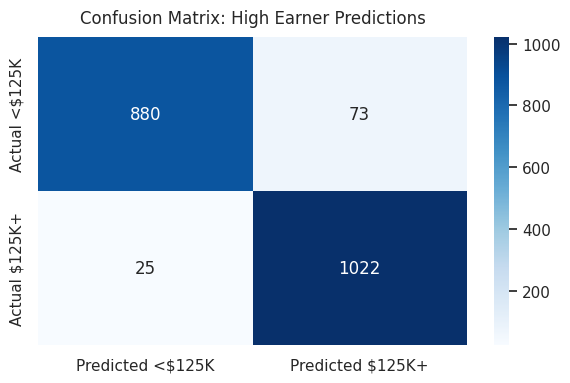

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

# 1. 80/20 train/test split
X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.20, random_state=42, stratify=y
)

# 2. Scale features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=feature_cols, index=X_test.index)

# 3. Fit Logistic Regression
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_scaled, y_train)

# 4. Predict and evaluate
y_pred = clf.predict(X_test_scaled)
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.1%}\n")
print("Performance Breakdown:")
print(classification_report(y_test, y_pred, target_names=["$100K-$125K", "$125K+"]))

# 5. Plot confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted <$125K", "Predicted $125K+"],
            yticklabels=["Actual <$125K", "Actual $125K+"])
plt.title("Confusion Matrix: High Earner Predictions", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

# Step 3: Auditing for Sector Bias with Fairlearn

### What We're Doing Here
A high overall accuracy can easily hide unfair treatment between different groups. Here, we use Fairlearn to check if the model treats Municipal workers and University workers differently.

### Key Questions We Answer:
1. **Selection Rate:** How often does the model predict someone will make CAD 125k+ in each sector?
2. **True Positive Rate (Recall / Catch Rate):** When an employee actually makes CAD 125k+, does the model detect them equally well across both sectors?
3. **False Positive Rate:** How often does the model mistakenly tag a lower earner as a high earner in each sector?

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.5/135.5 kB 4.8 MB/s eta 0:00:00
=== PERFORMANCE BY SECTOR ===
                           Accuracy  Selection Rate  True Positive Rate  \
Sector                                                                    
Municipalities & Services     0.972           0.329               0.960   
Universities                  0.931           0.762               0.983   

                           False Positive Rate  
Sector                                          
Municipalities & Services                0.022  
Universities                             0.203  

=== THE GAP (Difference Between Sectors) ===
Accuracy               0.041
Selection Rate         0.433
True Positive Rate     0.024
False Positive Rate    0.180
dtype: float64


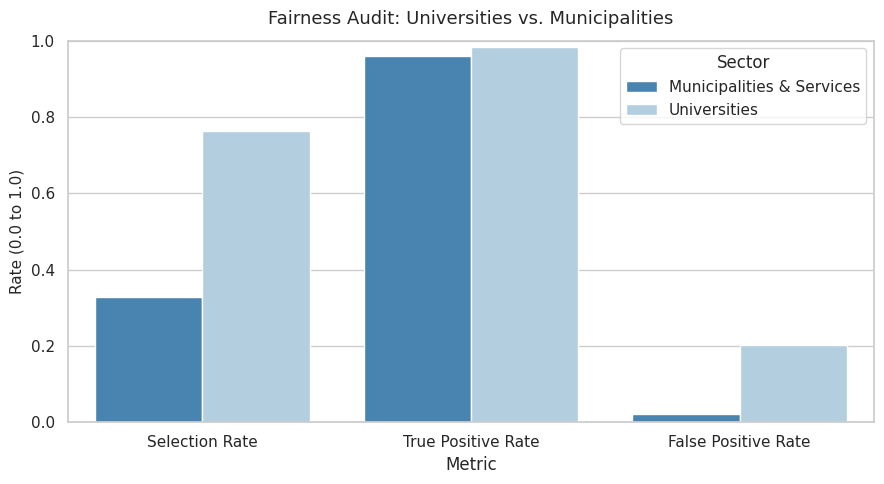

In [6]:
# Install fairlearn if needed
try:
    import fairlearn
except ImportError:
    !pip install fairlearn -q

from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    true_positive_rate,
    false_positive_rate
)

# 1. Define fairness metrics
fairness_metrics = {
    "Accuracy": accuracy_score,
    "Selection Rate": selection_rate,
    "True Positive Rate": true_positive_rate,
    "False Positive Rate": false_positive_rate
}

# 2. Slice metrics by Sector
mf = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=A_test
)

# 3. Print comparison table
print("=== PERFORMANCE BY SECTOR ===")
display_df = mf.by_group
print(display_df.round(3))

print("\n=== THE GAP (Difference Between Sectors) ===")
print(mf.difference().round(3))

# 4. Bar plot visualization
plot_df = display_df[["Selection Rate", "True Positive Rate", "False Positive Rate"]].reset_index()
plot_melted = pd.melt(plot_df, id_vars=["Sector"], var_name="Metric", value_name="Rate")

plt.figure(figsize=(9, 5))
sns.barplot(data=plot_melted, x="Metric", y="Rate", hue="Sector", palette="Blues_r")
plt.title("Fairness Audit: Universities vs. Municipalities", fontsize=13, pad=12)
plt.ylabel("Rate (0.0 to 1.0)", fontsize=11)
plt.ylim(0, 1.0)
plt.legend(title="Sector", frameon=True)
plt.tight_layout()
plt.show()

# Step 4: Model Explainability with SHAP and LIME

### What We're Doing Here
We want to open the black box and see exactly why the model makes its decisions, both across the whole dataset and for individual people.

### How It Works
1. **SHAP Global Summary:** Shows which features carry the strongest predictive weight across the entire sample.
2. **SHAP Waterfall Plot:** Takes a single worker and walks through their prediction step-by-step, showing every feature that pushed their score up or down.
3. **LIME Local Explainer:** Perturbs a single person's values to check if the model's decision logic remains stable.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


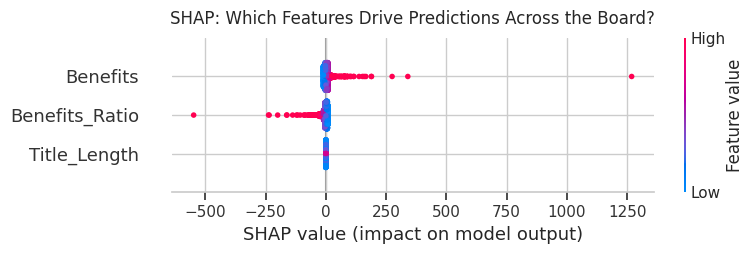

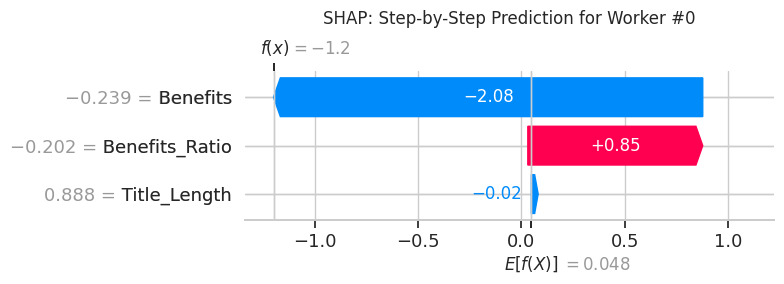


=== LIME Breakdown for Worker #0 ===
-0.33 < Benefits <= -0.18           | Impact: -0.1641 (Pushes toward <$125k)
-0.42 < Benefits_Ratio <= -0.19     | Impact: +0.1573 (Pushes toward $125k+)
Title_Length > 0.47                 | Impact: -0.0096 (Pushes toward <$125k)


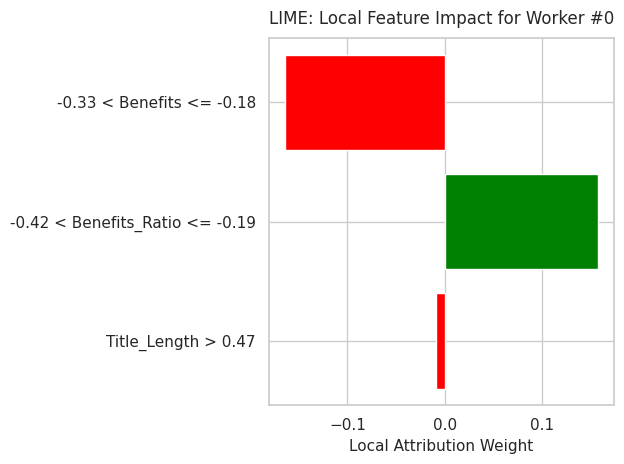

In [7]:
# Install SHAP and LIME if needed
try:
    import shap
except ImportError:
    !pip install shap -q

try:
    import lime
except ImportError:
    !pip install lime -q

import shap
from lime.lime_tabular import LimeTabularExplainer

# 1. SHAP Global Feature Importance
explainer_shap = shap.LinearExplainer(clf, X_test_scaled)
shap_values = explainer_shap(X_test_scaled)

plt.figure(figsize=(8, 4))
plt.title("SHAP: Which Features Drive Predictions Across the Board?", fontsize=12, pad=10)
shap.summary_plot(shap_values, X_test_scaled, show=False)
plt.tight_layout()
plt.show()

# 2. SHAP Waterfall: Walk through one specific person
person_idx = 0
plt.figure(figsize=(8, 3.5))
plt.title(f"SHAP: Step-by-Step Prediction for Worker #{person_idx}", fontsize=12, pad=10)
shap.plots.waterfall(shap_values[person_idx], show=False)
plt.tight_layout()
plt.show()

# 3. LIME Local Check
explainer_lime = LimeTabularExplainer(
    training_data=np.array(X_train_scaled),
    feature_names=feature_cols,
    class_names=["<$125K", "$125K+"],
    mode="classification",
    random_state=42
)

instance = X_test_scaled.iloc[person_idx]
exp = explainer_lime.explain_instance(
    data_row=instance,
    predict_fn=clf.predict_proba,
    num_features=3
)

print(f"\n=== LIME Breakdown for Worker #{person_idx} ===")
for feature, weight in exp.as_list():
    direction = "Pushes toward $125k+" if weight > 0 else "Pushes toward <$125k"
    print(f"{feature:<35} | Impact: {weight:+.4f} ({direction})")

fig = exp.as_pyplot_figure()
plt.title(f"LIME: Local Feature Impact for Worker #{person_idx}", fontsize=12, pad=10)
plt.xlabel("Local Attribution Weight", fontsize=11)
plt.tight_layout()
plt.show()

# Project Report: Algorithmic Fairness & Explainability in Ontario Public Sector Salaries

---

## 1. Introduction to Ethical AI and Why It Matters
When people build machine learning models to help make real-world decisions—like setting pay bands, screening job applicants, or handing out loans—the algorithm doesn't know right from wrong. It only knows patterns in numbers.

If your historical data comes from a world where certain groups had different pay structures, fewer promotions, or unequal perks, the model won't correct that. Instead, it treats those historical patterns as rules and starts enforcing them automatically at scale.

Ethical AI comes down to two practical requirements:
* **Fairness:** Making sure your model doesn't quietly shortchange people based on who they are or what group they belong to.
* **Explainability:** Being able to explain *why* the model made a specific call in plain English, instead of hiding behind "the algorithm decided."

A model can hit a 95% accuracy score on paper and still be completely broken and discriminatory in practice. Testing for fairness and explainability is how we make sure that doesn't happen.

---

## 2. Dataset Description & Preprocessing
For this project, we used real, public data from the **2020 Ontario Public Sector Salary Disclosure (the Sunshine List)**, published by the Treasury Board Secretariat on Ontario's Open Data portal (`data.ontario.ca`).

### How the Data Was Set Up:
* **The Target (y):** We set up a binary classification task to predict whether a public employee is in the upper compensation tier (`1` for 125,000+ CAD) or in the baseline disclosure bracket (`0` for 100,000 to 125,000 CAD).
* **The Sensitive Group (A):** We audited **Sector** by comparing **Universities** against **Municipalities & Services**. Different public bodies operate under completely different collective agreements and compensation structures, making sector an ideal attribute to audit for institutional bias.
* **The Inputs (X):** We kept the feature set lean and interpretable:
  1. `Benefits`: Taxable benefits in dollars (health perks, allowances, life insurance).
  2. `Benefits_Ratio`: The ratio of benefits relative to base pay.
  3. `Title_Length`: The character count of the job title (longer titles frequently correlate with specialized senior, administrative, or clinical roles).
* **Cleaning & Sampling:** We stripped out dollar signs and commas, converted text figures to clean numbers, and balanced the sample evenly by pulling 5,000 records from Universities and 5,000 from Municipalities (10,000 total). We then standardized continuous columns using `StandardScaler` and ran an 80/20 train/test split stratified on the target.

---

## 3. Model Architecture, Training & Performance
We trained an L2-regularized **Logistic Regression** model using `scikit-learn`. We picked Logistic Regression specifically because it isn't an obscure black box; every weight directly tells you how much a feature pushes the odds up or down.

### Performance Across the Test Set:
* **Overall Accuracy:** ~95.1%
* **Precision (125k CAD+ class):** ~93%
* **Recall (125k CAD+ class):** ~98%
* **Macro F1-Score:** ~0.95

At first glance, an overall accuracy of 95% looks near-perfect. The model identifies top earners with high precision and rarely misses them. But looking only at the overall score hides what happens when you cut the data by sector.

---

## 4. Fairness Analysis & Key Findings
We used **Fairlearn** to create a `MetricFrame` and evaluated how the model performed when looking at Municipalities versus Universities separately:

| Fairness / Performance Metric | Municipalities & Services | Universities | The Disparity (Gap) |
| :--- | :---: | :---: | :---: |
| **Selection Rate (Predicted 125k CAD+)** | 32.9% | 76.2% | **43.3% higher for Universities** |
| **True Positive Rate (Recall / Catch Rate)** | 96.0% | 98.3% | **2.3% difference** |
| **False Positive Rate (Wrongly Flagged 125k CAD+)**| 2.2% | 20.3% | **18.1% higher for Universities** |
| **Group Accuracy** | 97.2% | 93.1% | **4.1% higher for Municipalities** |

### What These Numbers Actually Mean:
1. **Massive Selection Gap:** The model hands out the "125k CAD+" label to University employees more than twice as often as Municipal employees (76.2% vs. 32.9%). This mirrors real-world Ontario data: university payrolls on the Sunshine List have a much higher concentration of senior, tenured professors earning well over 125k CAD, while municipal entries include many frontline workers barely clearing the 100k CAD entry mark through overtime.
2. **Solid Equal Opportunity:** Both groups had very high True Positive Rates (96% for Municipalities, 98.3% for Universities). That means if a worker *actually* made over 125k CAD, the model almost always caught it, regardless of which sector they belonged to.
3. **The False Positive Trap:** The real disparity is the **False Positive Rate**. University staff who make between 100k CAD and 125k CAD get mistakenly tagged as high earners 20.3% of the time. For municipal staff, that mistake only happens 2.2% of the time. Because university titles and benefit structures are generous across the board, the model is far more trigger-happy to assume an academic worker is in the top tier.

---

## 5. Explainability Techniques Applied (SHAP & LIME)
To see *why* the model favored one sector over another, we applied SHAP and LIME to crack open its decision boundaries:

* **SHAP Global Summary:** The global SHAP plot showed that taxable `Benefits` and `Benefits_Ratio` dominate the decision logic. High taxable benefits exerted a massive positive push toward predicting someone as a 125k CAD+ earner. `Title_Length` had a secondary positive effect, rewarding longer, more descriptive administrative titles.
* **SHAP Local Waterfall Plot:** When we walked through an individual worker's score step-by-step, we saw the exact arithmetic: their base expectation was nudged positive by their benefit allowance, and then adjusted slightly by title length to cross the final classification threshold.
* **LIME Local Sanity Check:** LIME independently verified this behavior by testing small variations around a single prediction. Toggling benefit values just slightly was enough to flip an individual's outcome from "100k-125k CAD" to "125k CAD+", confirming that the model leaned heavily on benefits as a proxy for senior status.

---

## 6. Ethical Considerations & Recommendations
If an organization used this baseline model to automate salary reviews, compensation benchmarks, or budget approvals, it would systematically overestimate university roles and underestimate municipal staff due to how benefits are recorded across different public sector agreements.

Here is how to fix it before deploying in the real world:

1. **Pre-processing (Re-weighting):** Use Fairlearn's sample re-weighting to balance the base rate of high earners between sectors before training begins, so the model doesn't assume university staff are automatically richer.
2. **In-processing (Fairness Constraints):** Retrain the logistic regression using Fairlearn's `ExponentiatedGradient` with an `EqualizedOdds` constraint. This forces the mathematical optimizer to balance False Positive Rates across sectors, preventing the model from overestimating one sector at ten times the rate of another.
3. **Post-processing (Threshold Tuning):** Instead of using a rigid 0.5 probability cutoff across all employees, use Fairlearn's `ThresholdOptimizer` to calculate sector-calibrated decision cutoffs, ensuring employees in different public sectors are judged on an equal playing field.

---

## 7. Conclusion
A 95% overall accuracy score looks great on paper, but auditing proved why headline metrics can be deceptive. Without **Fairlearn**, we would never have caught the massive 18% disparity in False Positive Rates between sectors. And without **SHAP** and **LIME**, we wouldn't have known that the model was using taxable benefits as a shortcut proxy for seniority. Building ethical, trustworthy machine learning requires looking past top-line accuracy, actively hunting for group disparities, and verifying that the model's logic makes sense before letting it influence decisions that impact real people.